# Gaussian Mixture Modeling Regimes

In [1]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
filtered_residuals = pd.read_csv("../data/manipulated/pr_filtered_residuals.csv", index_col=0, parse_dates=True)
train_residuals = pd.read_csv("../data/manipulated/residuals_train.csv", index_col=0, parse_dates=True)

train_start = train_residuals.index.min()
train_end = train_residuals.index.max()

filtered_train_residuals = filtered_residuals.loc[train_start:train_end]

cointegration_pairs = pd.read_csv('../data/manipulated/cointegrated_pairs.csv')

In [4]:
cointegration_pairs.head()

,asset_a,asset_b,pvalue,beta
0,ACN,MSI,0.0,1.151615
1,CDW,HAS,0.0,1.245633
2,CTSH,CSX,0.0,0.874569
3,CTSH,ACN,0.0,0.832885
4,AMCR,STZ,0.0,0.967045


In [5]:
def plot_bic(
        spread: pd.Series,
        k_range: range = [2, 3, 4, 5]
        ) -> None:
        """
        Plot the Bayesian Information Criterion (BIC) for different numbers of components in a Gaussian Mixture Model.
        """

        X = spread.values.reshape(-1, 1)
        bic_scores = []

        for k in k_range:
                gmm = GaussianMixture(
                n_components=k,
                covariance_type="full",
                random_state=42,
                n_init=5,          # multiple initialisations for stability
                )
                gmm.fit(X)
                bic_scores.append((k, gmm.bic(X)))

        plt.plot([k for k, _ in bic_scores], [bic for _, bic in bic_scores], marker='o')
        plt.title('BIC Scores for GMM')
        plt.xlabel('Number of Components (k)')
        plt.ylabel('BIC Score')
        plt.xticks([k for k, _ in bic_scores])
        plt.grid()
        plt.show()

In [6]:
def select_best_k(
    spread: pd.Series,
    k_range: range = [2, 3, 4, 5],
    ) -> int:
    """
    Select the optimal number of GMM components using BIC.

    Lower BIC => better model.

    Args:
        spread:  1D spread time series (training portion only).
        k_range: Range of k values to evaluate.

    Returns:
        best_k:  Optimal number of components.
        bic_scores: List of (k, bic) tuples for all tested values.
    """
    X = spread.values.reshape(-1, 1)
    bic_scores = []

    for k in k_range:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=42,
            n_init=5,          # multiple initialisations for stability
        )
        gmm.fit(X)
        bic_scores.append((k, gmm.bic(X)))

    best_k = min(bic_scores, key=lambda x: x[1])[0]
    return best_k

In [9]:
def fit_gmm(
    spread: pd.Series,
    n_components: int,
) -> GaussianMixture:
    """
    Fit a GaussianMixture model to a spread series.

    Args:
        spread:       1D spread time series (training portion only).
        n_components: Number of Gaussian components (regimes).

    Returns:
        Fitted GaussianMixture object.
    """
    X = spread.values.reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42,
        n_init=5,
    )
    gmm.fit(X)
    return gmm

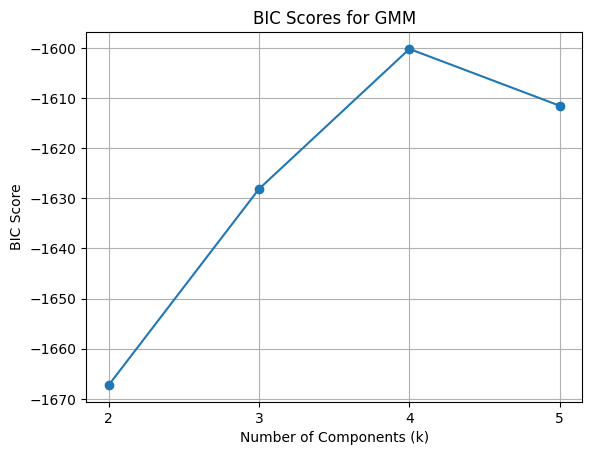

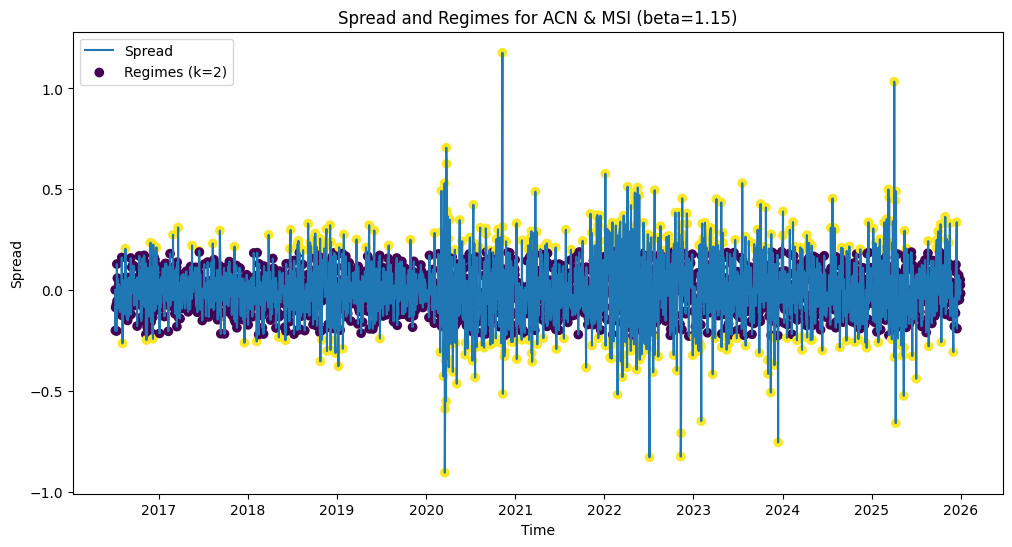

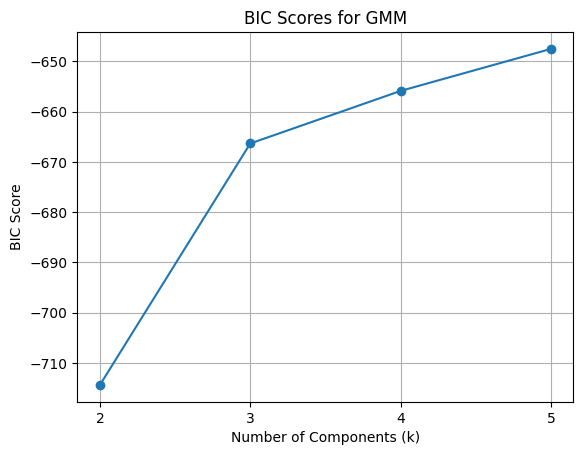

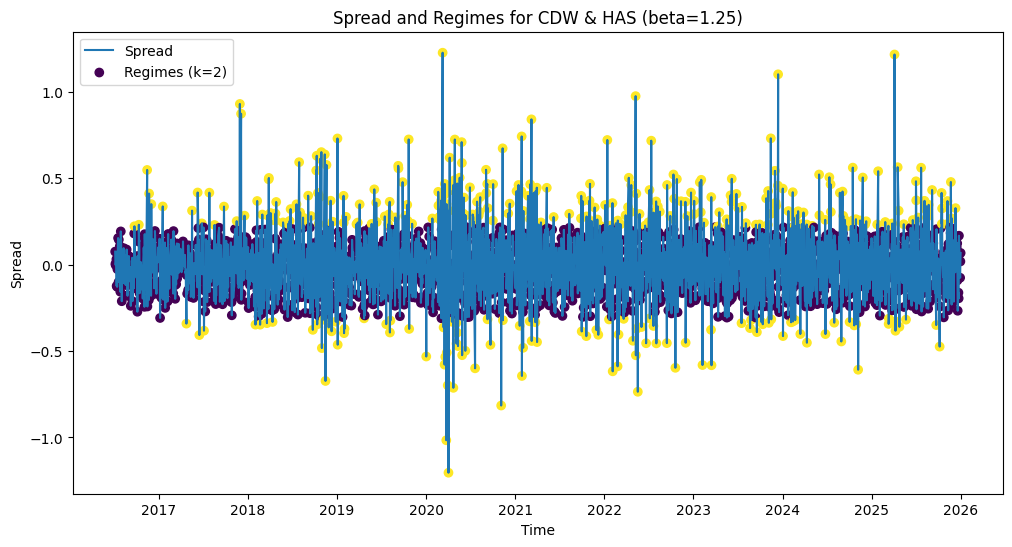

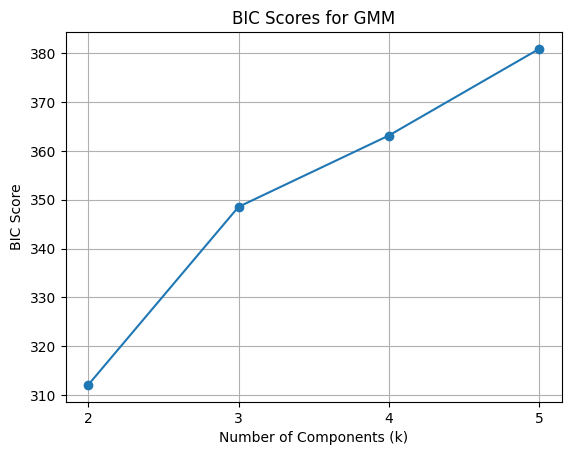

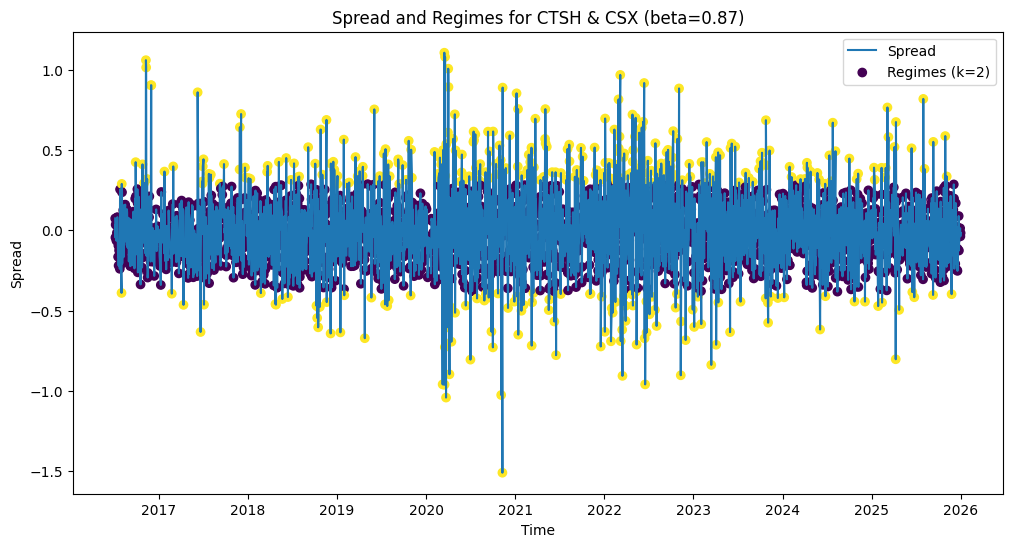

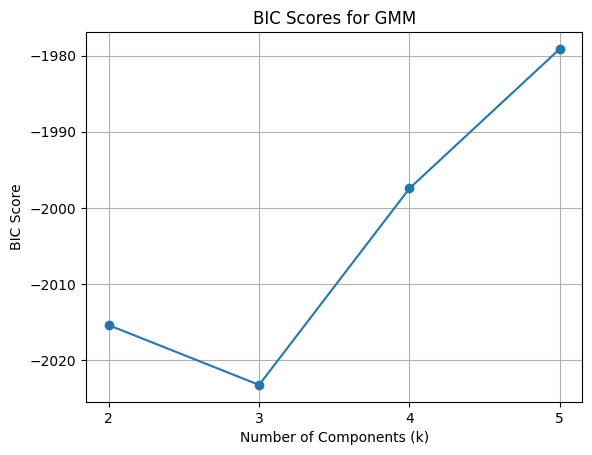

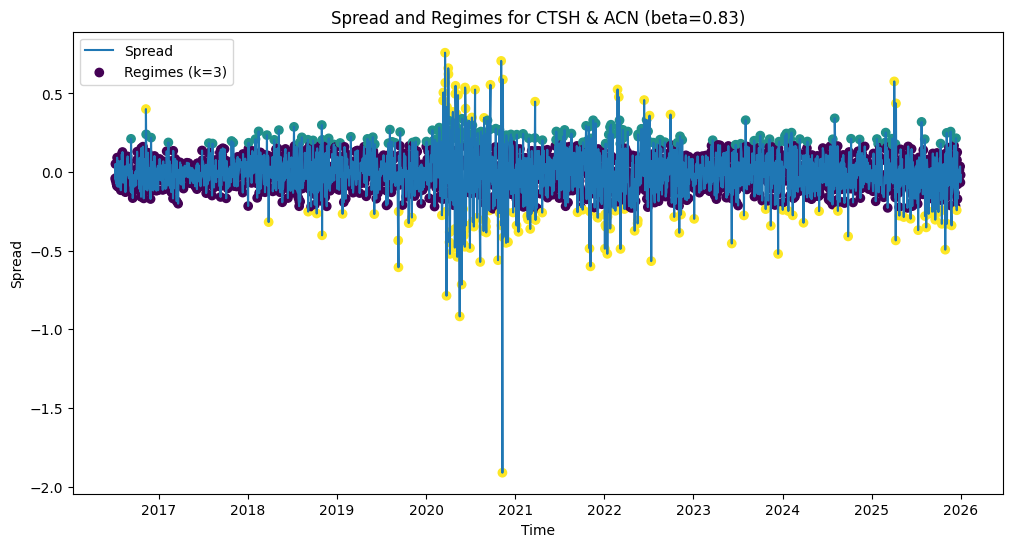

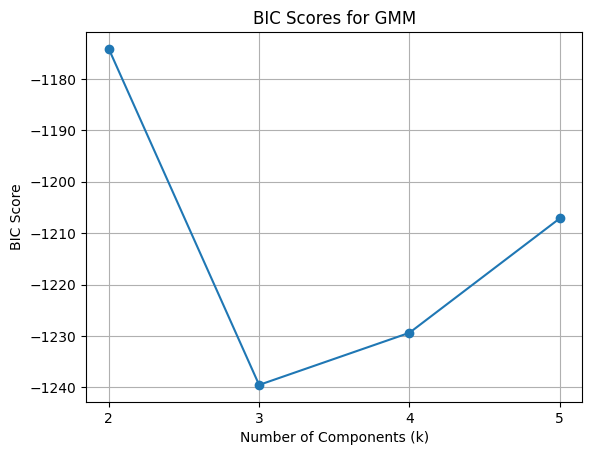

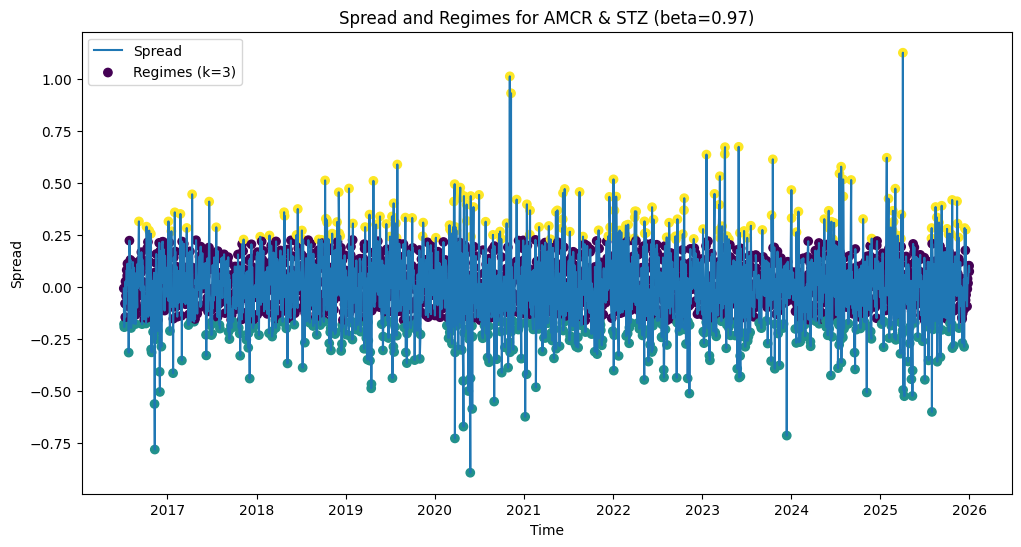

In [10]:
for i, row in cointegration_pairs.iterrows():
    a = row['asset_a']
    b = row['asset_b']
    beta = row['beta']
    
    train_spread = filtered_train_residuals[a] - beta * filtered_train_residuals[b]
    full_spread = filtered_residuals[a] - beta * filtered_residuals[b]
    
    best_k = select_best_k(train_spread)
    gmm = fit_gmm(train_spread, best_k)
    plot_bic(train_spread)

    regimes = gmm.predict(full_spread.values.reshape(-1, 1))
    plt.figure(figsize=(12, 6))
    plt.plot(full_spread.index, full_spread.values, label='Spread')
    plt.scatter(full_spread.index, full_spread.values, c=regimes, label=f'Regimes (k={best_k})', cmap='viridis', marker='o')
    plt.title(f'Spread and Regimes for {a} & {b} (beta={beta:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Spread')
    plt.legend()
    plt.show()

    if i >= 4:  # Limit to first 5 pairs for demonstration
        break

In [11]:
for _, row in cointegration_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']
        
    train_spread = filtered_train_residuals[a] - beta * filtered_train_residuals[b]
    full_spread = filtered_residuals[a] - beta * filtered_residuals[b]
    
    best_k = select_best_k(train_spread)
    gmm = fit_gmm(train_spread, best_k)
    labels = gmm.predict(full_spread.values.reshape(-1, 1))
    
    # sort regimes by mean for consistency across pairs
    sorted_idx    = np.argsort(gmm.means_.flatten())
    remap         = {old: new for new, old in enumerate(sorted_idx)}
    sorted_labels = np.array([remap[l] for l in labels])
    
    # global z-score
    z_scores = (full_spread - full_spread.mean()) / full_spread.std()
    
    # calm regime = lowest std after sorting
    sorted_stds = np.sqrt(gmm.covariances_.flatten())[sorted_idx]
    calm_regime = int(np.argmin(sorted_stds))
    
    # signals: only enter in calm regime
    signal = pd.Series(0, index=full_spread.index)
    signal[(z_scores < -1.5) & (sorted_labels == calm_regime)] =  1
    signal[(z_scores >  1.5) & (sorted_labels == calm_regime)] = -1
    signal[z_scores.abs() < 0.3] = 0
    
    df = pd.DataFrame({
        'spread':  full_spread.values,
        'regime':  sorted_labels,
        'z_score': z_scores.values,
        'signal':  signal.values,
    }, index=full_spread.index)
    
    df.to_csv(f'../data/manipulated/spreads/{a}_{b}.csv')

print(f'saved {len(cointegration_pairs)} spread files')

saved 300 spread files


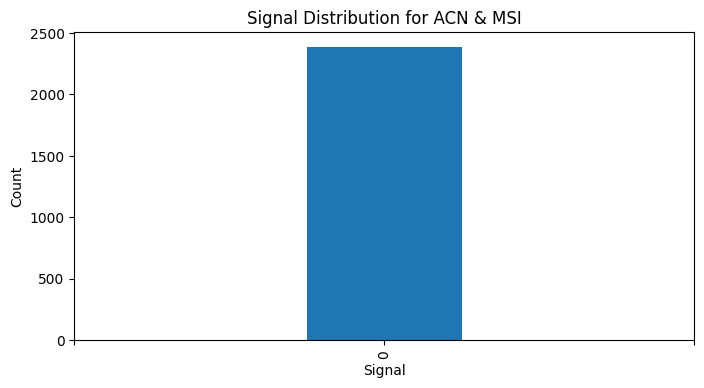

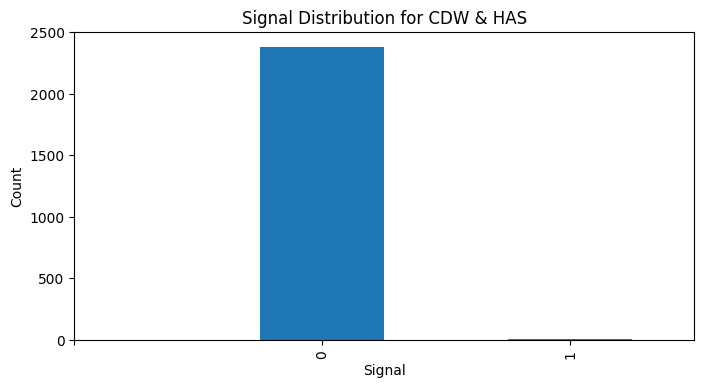

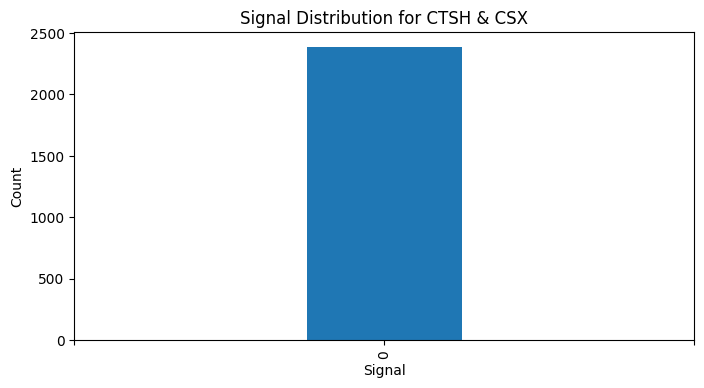

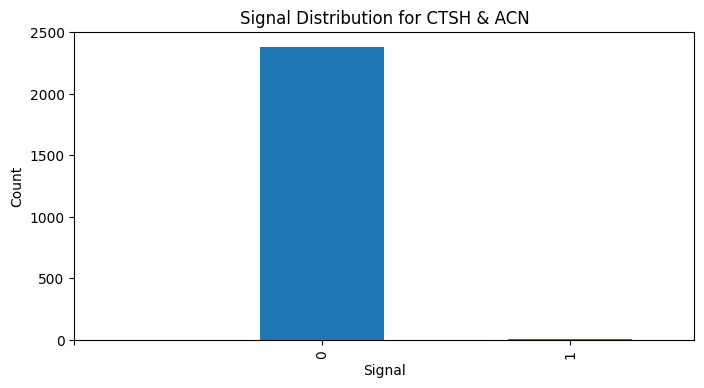

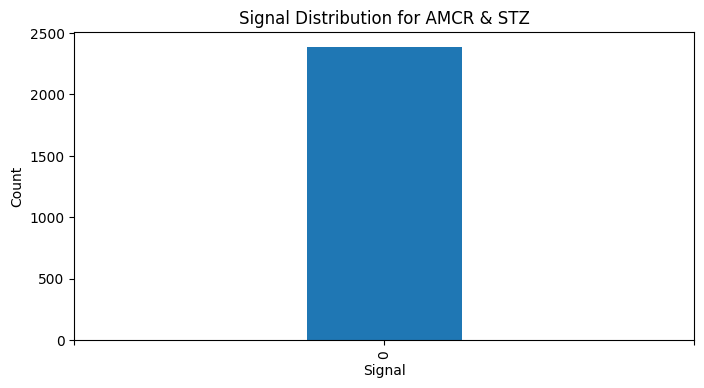

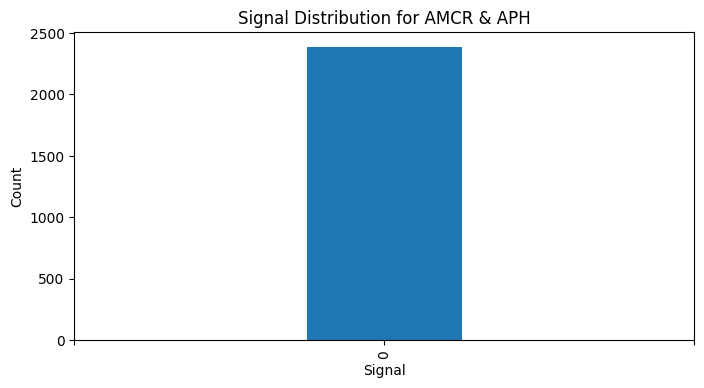

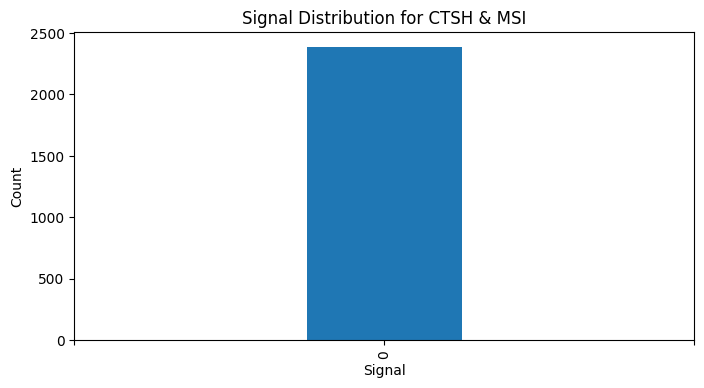

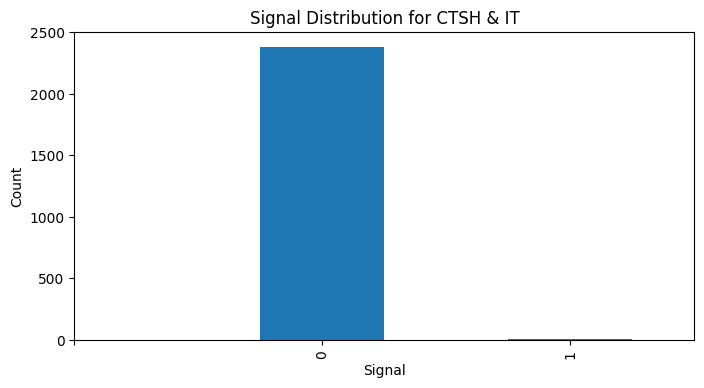

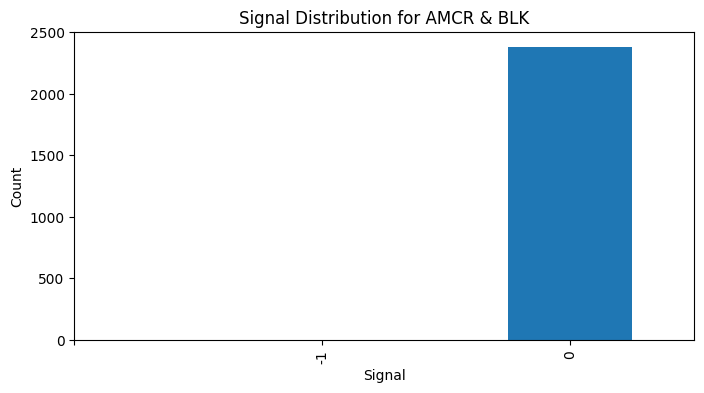

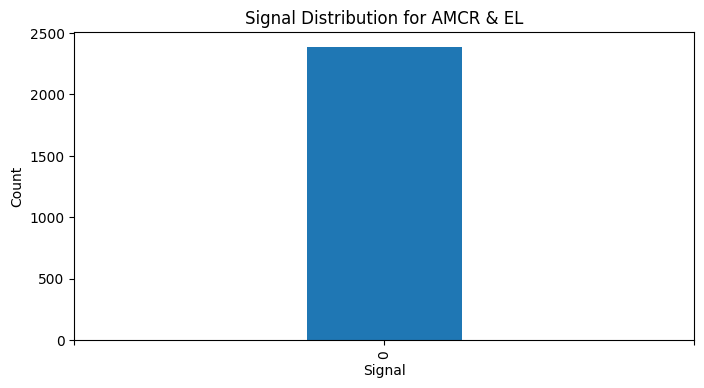

In [13]:
for i, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0)

    plt.figure(figsize=(8, 4))
    df['signal'].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Signal Distribution for {a} & {b}')
    plt.xlabel('Signal')
    plt.ylabel('Count')
    plt.xticks(ticks=[-1, 0, 1])
    plt.show()

    if i >= 9:  # Limit to first 10 pairs for demonstration
        break

Not enough spreads are being classified as tradeable.

In [15]:
# print signal distribution for each pair
for i, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0)

    print(f'Signal Distribution for {a} & {b}:')
    print(df['signal'].value_counts().sort_index())
    print()

    if i >= 19: # Limit to first 20 pairs for demonstration
        break

Signal Distribution for ACN & MSI:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for CDW & HAS:
signal
0    2384
1       3
Name: count, dtype: int64

Signal Distribution for CTSH & CSX:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for CTSH & ACN:
signal
0    2384
1       3
Name: count, dtype: int64

Signal Distribution for AMCR & STZ:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for AMCR & APH:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for CTSH & MSI:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for CTSH & IT:
signal
0    2384
1       3
Name: count, dtype: int64

Signal Distribution for AMCR & BLK:
signal
-1       2
 0    2385
Name: count, dtype: int64

Signal Distribution for AMCR & EL:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for AMCR & APO:
signal
0    2387
Name: count, dtype: int64

Signal Distribution for APO & CSX:
signal
0    2387
Name: count, dtype: int64

Sig

In [14]:
for i, row in cointegration_pairs.iterrows():
    filename = f"../data/manipulated/spreads/{row['asset_a']}_{row['asset_b']}.csv"
    df = pd.read_csv(filename, index_col=0)
    print(f'Z-Score Statistics for {row["asset_a"]} & {row["asset_b"]}:')
    print(df['z_score'].describe())
    print(df['z_score'].abs().quantile([0.8, 0.9, 0.95, 0.99]))
    print()

    if i >= 9:  # Limit to first 10 pairs for demonstration
        break

Z-Score Statistics for ACN & MSI:
count    2387.000000
mean        0.000000
std         1.000000
min        -5.669370
25%        -0.551346
50%        -0.045066
75%         0.541830
max         7.367435
Name: z_score, dtype: float64
0.80    1.162478
0.90    1.603848
0.95    1.955939
0.99    3.082999
Name: z_score, dtype: float64

Z-Score Statistics for CDW & HAS:
count    2.387000e+03
mean     1.227896e-17
std      1.000000e+00
min     -5.841288e+00
25%     -6.178306e-01
50%     -2.888313e-02
75%      5.383922e-01
max      5.928971e+00
Name: z_score, dtype: float64
0.80    1.130974
0.90    1.562980
0.95    2.005960
0.99    3.131253
Name: z_score, dtype: float64

Z-Score Statistics for CTSH & CSX:
count    2.387000e+03
mean     3.125555e-17
std      1.000000e+00
min     -5.876533e+00
25%     -6.114837e-01
50%     -5.029230e-02
75%      5.639231e-01
max      4.320577e+00
Name: z_score, dtype: float64
0.80    1.138356
0.90    1.577976
0.95    1.991540
0.99    3.269922
Name: z_score, dtype:

The z-score statistics for most pairs appear to be approximately standard normal. 

Lower z-score signal threshold, not triggering enough trades, all of them will be in relatively safe calm regime anyway.

In [16]:
for _, row in cointegration_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']
        
    train_spread = filtered_train_residuals[a] - beta * filtered_train_residuals[b]
    full_spread = filtered_residuals[a] - beta * filtered_residuals[b]
    
    best_k = select_best_k(train_spread)
    gmm = fit_gmm(train_spread, best_k)
    labels = gmm.predict(full_spread.values.reshape(-1, 1))
    
    # sort regimes by mean for consistency across pairs
    sorted_idx    = np.argsort(gmm.means_.flatten())
    remap         = {old: new for new, old in enumerate(sorted_idx)}
    sorted_labels = np.array([remap[l] for l in labels])
    
    # global z-score
    z_scores = (full_spread - full_spread.mean()) / full_spread.std()
    
    # calm regime = lowest std after sorting
    sorted_stds = np.sqrt(gmm.covariances_.flatten())[sorted_idx]
    calm_regime = int(np.argmin(sorted_stds))
    
    # signals: only enter in calm regime
    signal = pd.Series(0, index=full_spread.index)
    signal[(z_scores < -1) & (sorted_labels == calm_regime)] =  1
    signal[(z_scores >  1) & (sorted_labels == calm_regime)] = -1
    signal[z_scores.abs() < 0.2] = 0
    
    df = pd.DataFrame({
        'spread':  full_spread.values,
        'regime':  sorted_labels,
        'z_score': z_scores.values,
        'signal':  signal.values,
    }, index=full_spread.index)
    
    df.to_csv(f'../data/manipulated/spreads/{a}_{b}.csv')

print(f'saved {len(cointegration_pairs)} spread files')

saved 300 spread files


In [18]:
# print signal distribution for each pair
for i, row in cointegration_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    filename = f"../data/manipulated/spreads/{a}_{b}.csv"
    df = pd.read_csv(filename, index_col=0)

    print(f'Signal Distribution for {a} & {b}:')
    print(df['signal'].value_counts().sort_index())
    print()

    if i >= 19:
        break

Signal Distribution for ACN & MSI:
signal
-1      85
 0    2151
 1     151
Name: count, dtype: int64

Signal Distribution for CDW & HAS:
signal
-1      27
 0    2156
 1     204
Name: count, dtype: int64

Signal Distribution for CTSH & CSX:
signal
-1      53
 0    2165
 1     169
Name: count, dtype: int64

Signal Distribution for CTSH & ACN:
signal
-1      77
 0    2159
 1     151
Name: count, dtype: int64

Signal Distribution for AMCR & STZ:
signal
-1     117
 0    2270
Name: count, dtype: int64

Signal Distribution for AMCR & APH:
signal
-1     122
 0    2227
 1      38
Name: count, dtype: int64

Signal Distribution for CTSH & MSI:
signal
-1     101
 0    2279
 1       7
Name: count, dtype: int64

Signal Distribution for CTSH & IT:
signal
-1      96
 0    2141
 1     150
Name: count, dtype: int64

Signal Distribution for AMCR & BLK:
signal
-1     174
 0    2213
Name: count, dtype: int64

Signal Distribution for AMCR & EL:
signal
-1     146
 0    2171
 1      70
Name: count, dtype: int

Much more desirable split now.